In [1]:
pip install python-binance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\asus\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [1]:
from binance.client import Client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import random
import os
from sklearn.preprocessing import StandardScaler



In [8]:


# Initialize Binance client (no API key needed for public data)
client = Client()

# Function to fetch historical btc/usd candlestick data
def get_btc_data(interval, start_date, end_date=None):
    """
    interval: '1h' for hourly, '1d' for daily
    start_date: format '1 Jan 2021'
    end_date: optional, format '1 Jan 2026'
    """
    klines = client.get_historical_klines(
        "BTCUSDT", interval, start_date, end_date
    )

    # Convert to DataFrame
    df = pd.DataFrame(klines, columns=[
        "timestamp", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "trades",
        "taker_buy_base", "taker_buy_quote", "ignore"
    ])

    # Convert timestamp to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")

    # Keep only useful columns
    df = df[["timestamp", "open", "high", "low", "close", "volume"]]
    df[["open","high","low","close","volume"]] = df[["open","high","low","close","volume"]].astype(float)
    df = df.set_index("timestamp")
    return df


In [9]:
# btc_daily = get_btc_data("1d", "1 Jan 2017")

# Get hourly BTC data from 2021 to now
btc_hourly = get_btc_data("1h", "1 Jan 2021")

# btc_hourly.to_csv("btc_hourly.csv", index=False)

In [6]:
pd.read_csv('btc_hourly.csv')


,timestamp,open,high,low,close,volume
0,2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009
1,2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916
2,2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691
3,2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249
4,2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807
...,...,...,...,...,...,...
73890,2026-01-26 06:00:00,87826.01,88031.73,87764.00,87937.44,915.629790
73891,2026-01-26 07:00:00,87937.45,88074.48,87701.72,88000.64,768.409880
73892,2026-01-26 08:00:00,88000.64,88424.45,87846.89,87975.39,790.547230
73893,2026-01-26 09:00:00,87975.39,88000.00,87600.69,87663.12,543.284740


In [10]:
btc_hourly.head(),btc_hourly.tail()

(                         open      high       low     close       volume
 timestamp                                                               
 2021-01-01 00:00:00  28923.63  29031.34  28690.17  28995.13  2311.811445
 2021-01-01 01:00:00  28995.13  29470.00  28960.35  29409.99  5403.068471
 2021-01-01 02:00:00  29410.00  29465.26  29120.03  29194.65  2384.231560
 2021-01-01 03:00:00  29195.25  29367.00  29150.02  29278.40  1461.345077
 2021-01-01 04:00:00  29278.41  29395.00  29029.40  29220.31  2038.046803,
                          open      high       low     close     volume
 timestamp                                                             
 2026-02-26 04:00:00  68216.87  68860.00  68179.62  68571.36  587.55874
 2026-02-26 05:00:00  68571.36  68571.37  68127.58  68443.81  486.81983
 2026-02-26 06:00:00  68443.82  68522.00  68042.90  68176.75  618.63359
 2026-02-26 07:00:00  68176.75  68290.18  67817.87  67825.04  840.14406
 2026-02-26 08:00:00  67825.05  68110.86  67792.0

Text(0.5, 1.0, 'Return vs Lag-1 Return')

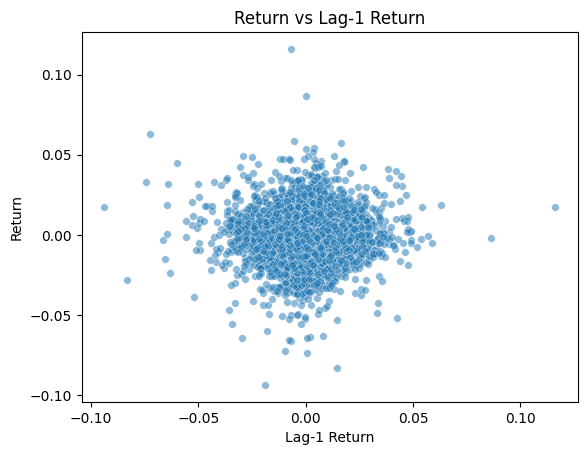

In [11]:
btc_hourly['close_log_return'] = np.log(btc_hourly['close']/btc_hourly['close'].shift())
btc_hourly['close_log_return_lag_1'] = btc_hourly['close_log_return'].shift()

data = btc_hourly.dropna()[['close_log_return', 'close_log_return_lag_1']]

sns.scatterplot(
    data=data,
    x='close_log_return_lag_1',
    y='close_log_return',
    s=30,
    alpha=0.5
)

plt.xlabel("Lag-1 Return")
plt.ylabel("Return")
plt.title("Return vs Lag-1 Return")


<Axes: >

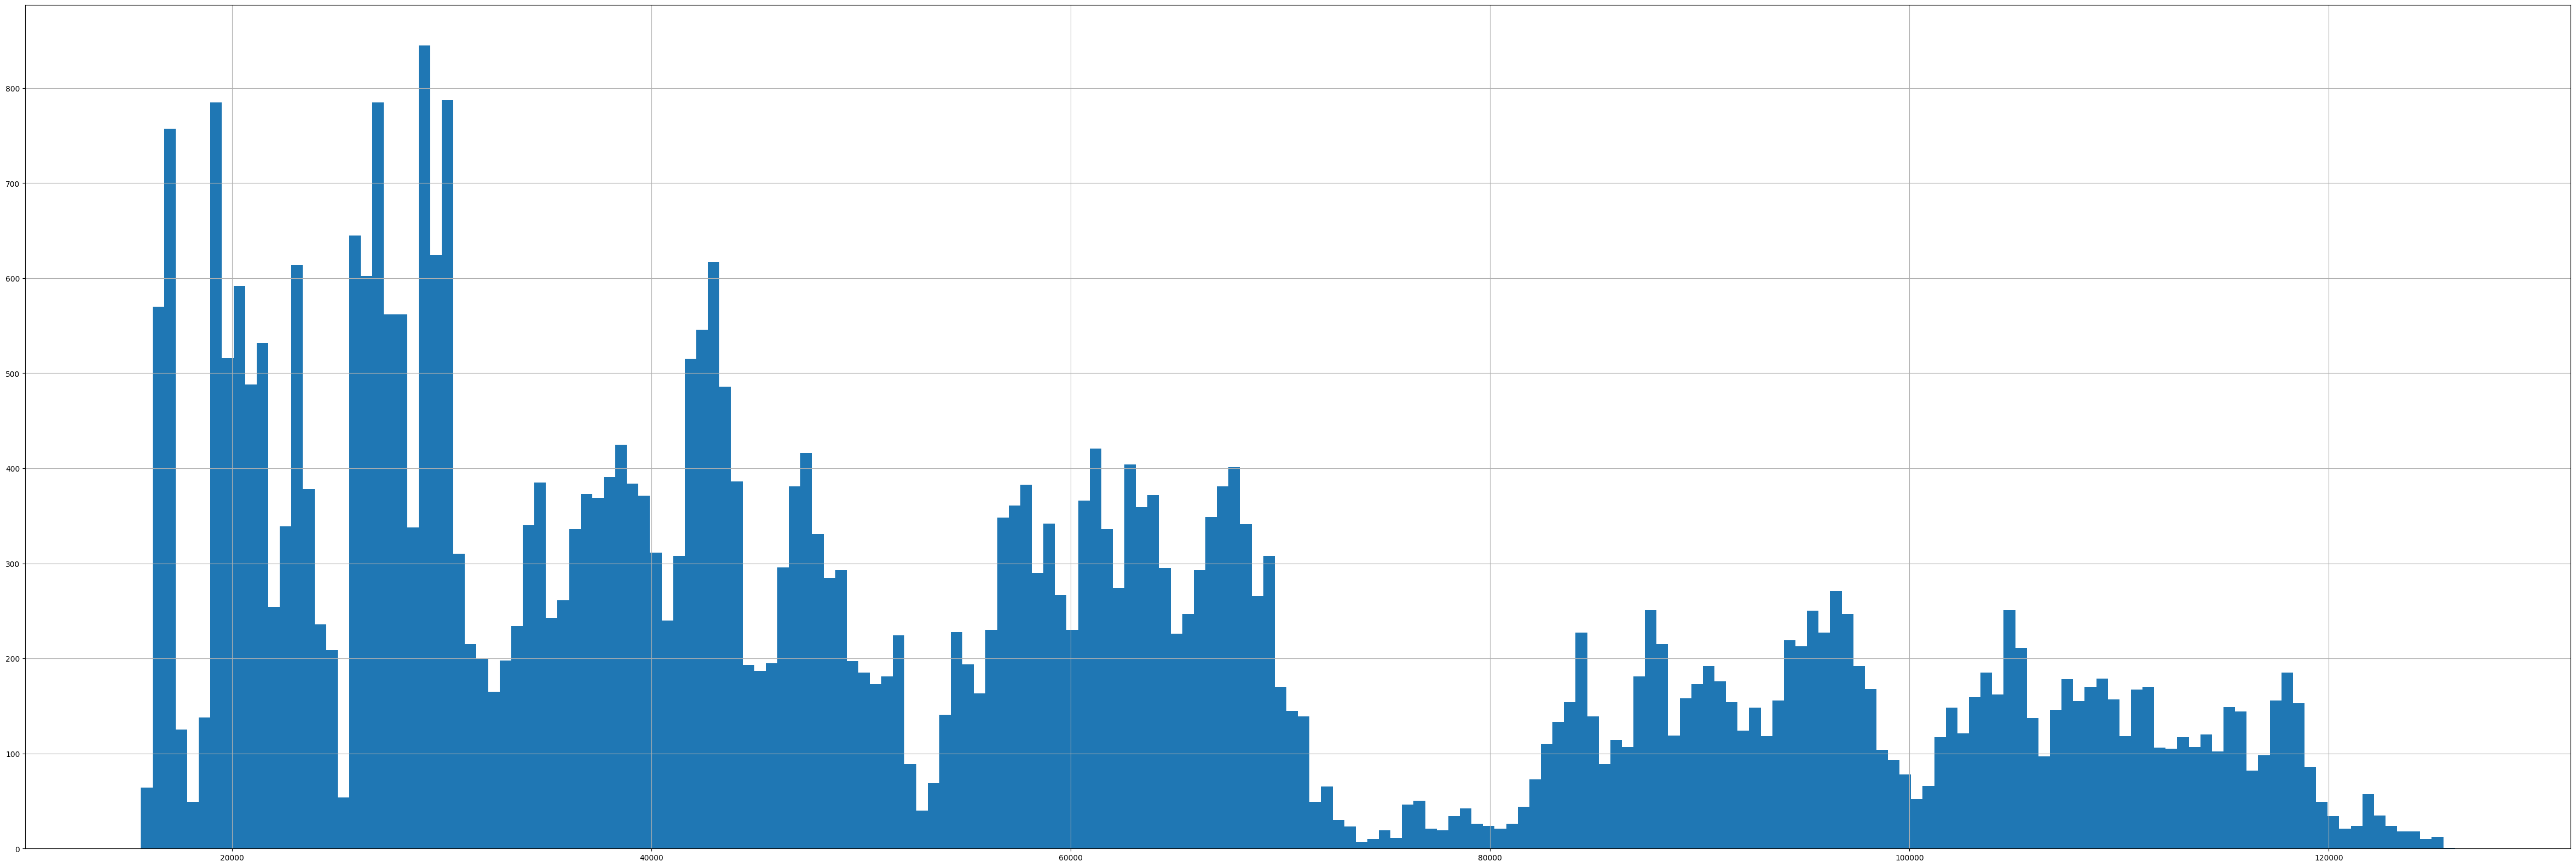

In [12]:
btc_hourly['close'].hist(bins=200, figsize=(60,20))

<Axes: >

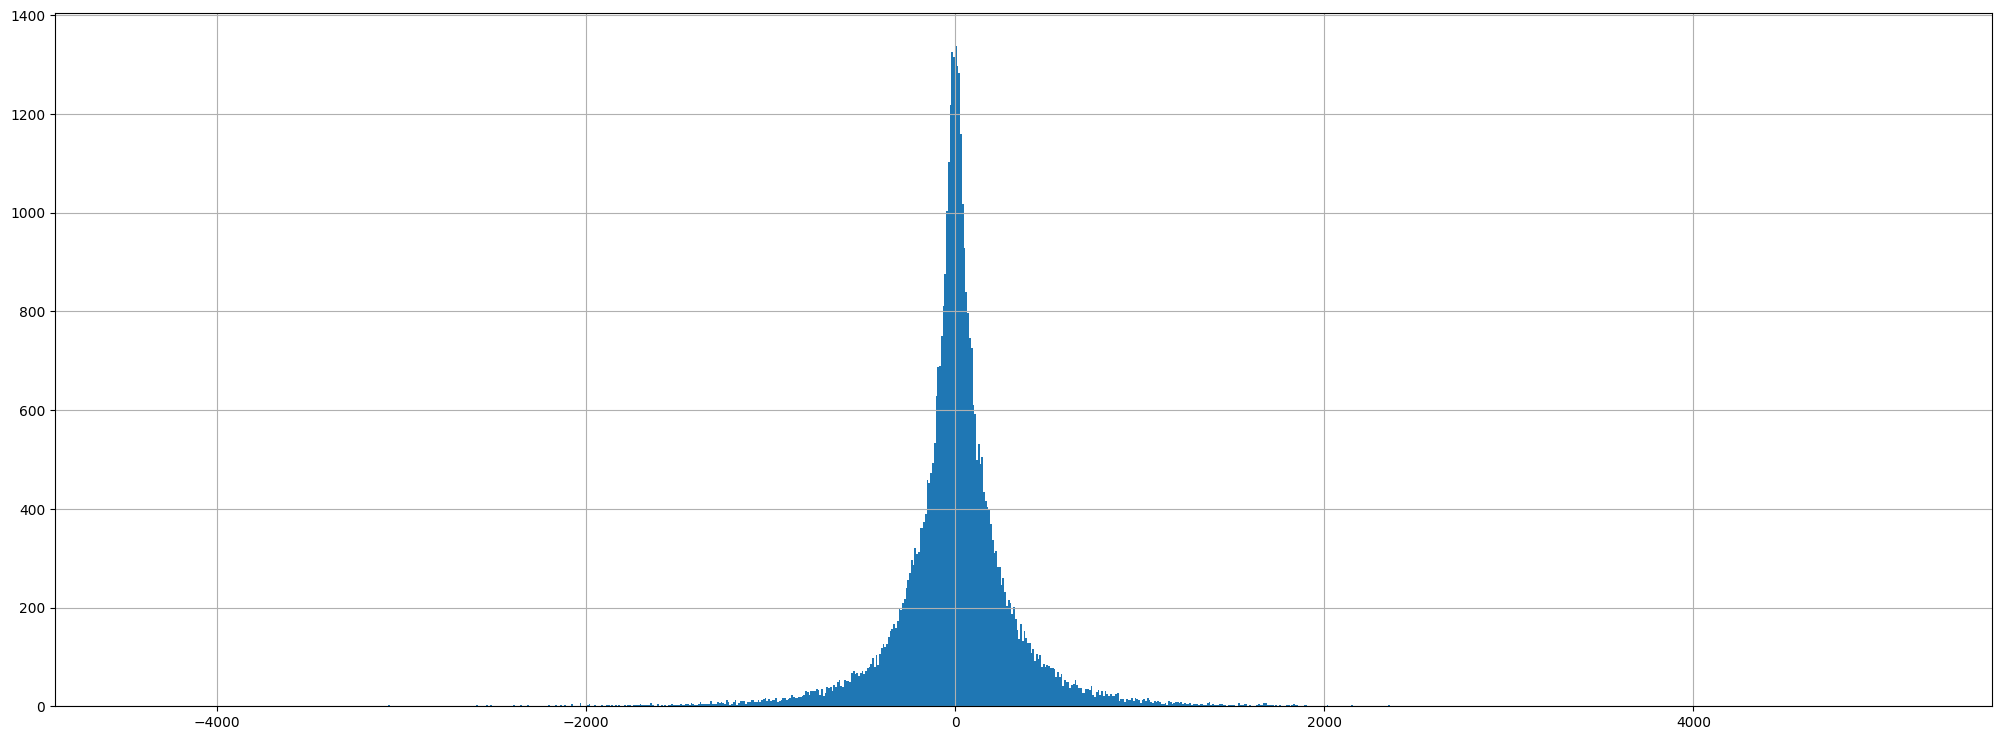

In [13]:
# Use differences to see a familiar distribution
btc_hourly['close'].diff().hist(bins=1000, figsize=(25,9))


In [14]:
btc_hourly['close'].diff().describe()


count    45162.000000
mean         0.865570
std        344.094075
min      -4402.670000
25%       -112.717500
50%          1.840000
75%        122.197500
max       5142.300000
Name: close, dtype: float64

In [15]:
btc_hourly['close_log_return'].describe()

count    45162.000000
mean         0.000019
std          0.006392
min         -0.093810
25%         -0.002321
50%          0.000043
75%          0.002470
max          0.116145
Name: close_log_return, dtype: float64

<Axes: >

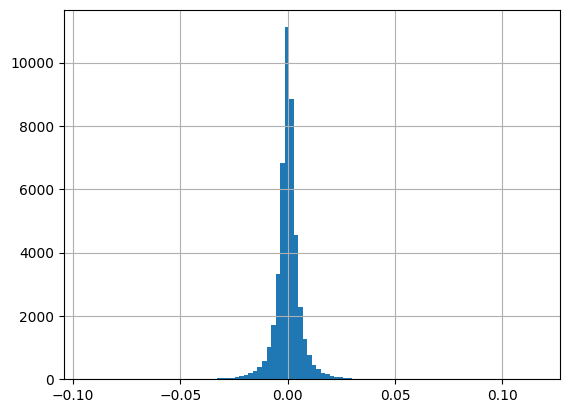

In [16]:
btc_hourly['close_log_return'].hist(bins=100)

In [17]:
btc_hourly['close_log_return'].skew()

np.float64(-0.20900755466755788)

In [18]:

btc_hourly['close_log_return_lag_2'] = btc_hourly['close_log_return'].shift(2)
btc_hourly['close_log_return_lag_3'] = btc_hourly['close_log_return'].shift(3)
btc_hourly['close_log_return_lag_4'] = btc_hourly['close_log_return'].shift(4)
btc_hourly['close_log_return_lag_5'] = btc_hourly['close_log_return'].shift(5)

btc_hourly = btc_hourly.dropna()
btc_hourly[['close_log_return','close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3']]

,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
timestamp,,,,
2021-01-01 06:00:00,-0.000434,-0.001140,-0.001986,0.002865
2021-01-01 07:00:00,-0.002798,-0.000434,-0.001140,-0.001986
2021-01-01 08:00:00,-0.003196,-0.002798,-0.000434,-0.001140
2021-01-01 09:00:00,0.006948,-0.003196,-0.002798,-0.000434
2021-01-01 10:00:00,0.000740,0.006948,-0.003196,-0.002798
...,...,...,...,...
2026-02-26 04:00:00,0.005183,-0.000595,0.000134,-0.001284
2026-02-26 05:00:00,-0.001862,0.005183,-0.000595,0.000134
2026-02-26 06:00:00,-0.003910,-0.001862,0.005183,-0.000595


In [19]:
btc_hourly[['close_log_return','close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3','close_log_return_lag_4', 'close_log_return_lag_5']].corr()

,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4,close_log_return_lag_5
close_log_return,1.000000,-0.005067,-0.011161,-0.000087,-0.015181,-0.004222
close_log_return_lag_1,-0.005067,1.000000,-0.005055,-0.011154,-0.000079,-0.015200
close_log_return_lag_2,-0.011161,-0.005055,1.000000,-0.005069,-0.011152,-0.000079
close_log_return_lag_3,-0.000087,-0.011154,-0.005069,1.000000,-0.005085,-0.011118
close_log_return_lag_4,-0.015181,-0.000079,-0.011152,-0.005085,1.000000,-0.005136
close_log_return_lag_5,-0.004222,-0.015200,-0.000079,-0.011118,-0.005136,1.000000


Label price moves:
1 => Long => Price moves up
0 => Short => Price moves down

In [21]:
btc_hourly['close_log_return_direction'] = btc_hourly['close_log_return'].map(lambda x: 1 if x > 0 else 0)
btc_hourly[['close_log_return','close_log_return_direction']]

,close_log_return,close_log_return_direction
timestamp,,
2021-01-01 06:00:00,-0.000434,0
2021-01-01 07:00:00,-0.002798,0
2021-01-01 08:00:00,-0.003196,0
2021-01-01 09:00:00,0.006948,1
2021-01-01 10:00:00,0.000740,1
...,...,...
2026-02-26 04:00:00,0.005183,1
2026-02-26 05:00:00,-0.001862,0
2026-02-26 06:00:00,-0.003910,0


In [22]:
# Check Target Balance
btc_hourly['close_log_return_direction'].value_counts()

close_log_return_direction
1    22831
0    22326
Name: count, dtype: int64

In [23]:
# Select features and the target
features = ['close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3','close_log_return_lag_4', 'close_log_return_lag_5']
target = 'close_log_return_direction'

no_features = len(features)


In [232]:
# Split Data into Train/Test
start = 0
period = 480
window = 3

def split_data(data, features, target, start, window, period):
    
    insert_data = data[[*features, target]].copy()
    insert_data = insert_data[start:]

    coupled_split = []

    for i in range(0, len(insert_data)-period-window, window):
        train_i, test_i = insert_data[i:i+period].copy(), insert_data.iloc[i+period:i+window+period].copy()
        pos_target = np.sum(train_i[target]>0)
        neg_target = np.sum(train_i[target]==0)
        if 0.98<pos_target/(neg_target)<1.02:    
            coupled_split.append((train_i, test_i))
        else:
            print(train_i.index[0], 'is not even')
    print(insert_data,'data')

    return coupled_split

btc_hourly_train_test = split_data(btc_hourly, features, target, start,  window, period)

2021-01-01 06:00:00 is not even
2021-01-01 09:00:00 is not even
2021-01-01 12:00:00 is not even
2021-01-01 15:00:00 is not even
2021-01-01 18:00:00 is not even
2021-01-01 21:00:00 is not even
2021-01-02 00:00:00 is not even
2021-01-02 03:00:00 is not even
2021-01-02 06:00:00 is not even
2021-01-02 09:00:00 is not even
2021-01-02 12:00:00 is not even
2021-01-02 15:00:00 is not even
2021-01-02 18:00:00 is not even
2021-01-02 21:00:00 is not even
2021-01-03 00:00:00 is not even
2021-01-03 06:00:00 is not even
2021-01-03 09:00:00 is not even
2021-01-03 15:00:00 is not even
2021-01-03 18:00:00 is not even
2021-01-03 21:00:00 is not even
2021-01-04 00:00:00 is not even
2021-01-04 03:00:00 is not even
2021-01-04 06:00:00 is not even
2021-01-04 09:00:00 is not even
2021-01-04 12:00:00 is not even
2021-01-04 15:00:00 is not even
2021-01-04 18:00:00 is not even
2021-01-04 21:00:00 is not even
2021-01-05 00:00:00 is not even
2021-01-05 03:00:00 is not even
2021-01-05 06:00:00 is not even
2021-01-

In [233]:
len(btc_hourly_train_test)

3642

In [234]:

# Set reproducibility
SEED = 99
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


def scale_data(train_data, test_data, features, target):
    # Fit scaler on training set only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_data[features].values)
    X_test_scaled  = scaler.transform(test_data[features].values)
    print()
    # Convert to PyTorch tensors
    X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_test  = torch.tensor(X_test_scaled,  dtype=torch.float32)
        
    y_train = torch.tensor(train_data[target].values, dtype=torch.float32).unsqueeze(1)
    y_test  = torch.tensor(test_data[target].values, dtype=torch.float32).unsqueeze(1)

    return X_train, y_train, X_test, y_test



In [235]:
# Define model - Logistic Regression
class LogisticRegression(nn.Module):
    def __init__(self, input_size):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return self.linear(x)


model = LogisticRegression(no_features)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop
def train_test_model(model, criterion, optimizer, train, test, features, target):
    
    X_train, y_train, X_test, y_test = scale_data(train, test, features, target)

    for epoch in range(501):
        optimizer.zero_grad()
        y_pred_logits = model(X_train)
        loss = criterion(y_pred_logits.squeeze(), y_train.squeeze())
        loss.backward()   
        optimizer.step()
    
        if epoch % 500 == 0:
            print("Epoch:", epoch, "Loss:", loss.item())

    # Check trained parameters
    #print("\nFinal weight:", model.linear.weight.data)
    #print("Final bias:", model.linear.bias.data)

    # Evaluation on the test set
    with torch.no_grad():
        y_pred_logits = model(X_test)
        y_pred_proba = torch.sigmoid(y_pred_logits)
        y_pred_binary = (y_pred_proba > 0.5).float()
    
    y_test_np = y_test.squeeze().numpy()
    y_pred_binary_np = y_pred_binary.squeeze().numpy()
    y_pred_proba_np = y_pred_proba.squeeze().numpy()
       
    print("\n--- Model Evaluation ---")
    print(f"Date: {test.index}")
#    print(f"Testing Sample: {y_test}")
 #   print(f"Prediction binary: {y_pred_binary}")
    return y_test_np, y_pred_binary_np, y_pred_proba_np, test.index

In [236]:
y_test_bin = []
test_time_stamp = []
for train, test in btc_hourly_train_test:
    y_test_res = train_test_model(model, criterion, optimizer, train, test, features, target)
    y_test_bin.append((y_test_res[:3]))
    test_time_stamp.append(y_test_res[3])


Epoch: 0 Loss: 0.8119844198226929
Epoch: 500 Loss: 0.6976922154426575

--- Model Evaluation ---
Date: DatetimeIndex(['2021-01-23 03:00:00', '2021-01-23 04:00:00',
               '2021-01-23 05:00:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)

Epoch: 0 Loss: 0.6969398260116577
Epoch: 500 Loss: 0.685940146446228

--- Model Evaluation ---
Date: DatetimeIndex(['2021-01-23 12:00:00', '2021-01-23 13:00:00',
               '2021-01-23 14:00:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)

Epoch: 0 Loss: 0.686991810798645
Epoch: 500 Loss: 0.6853772401809692

--- Model Evaluation ---
Date: DatetimeIndex(['2021-01-27 03:00:00', '2021-01-27 04:00:00',
               '2021-01-27 05:00:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)

Epoch: 0 Loss: 0.6856194138526917
Epoch: 500 Loss: 0.6855159997940063

--- Model Evaluation ---
Date: DatetimeIndex(['2021-01-27 06:00:00', '2021-01-27 07:00:00',
               '2021-01-27 0

In [184]:
test_idx = pd.Index([])
for i in test_time_stamp:
    test_idx = test_idx.union(i)

In [185]:
test_idx

Index([2021-01-28 06:00:00, 2021-01-28 07:00:00, 2021-01-28 08:00:00,
       2021-01-28 09:00:00, 2021-01-28 10:00:00, 2021-01-28 11:00:00,
       2021-01-28 12:00:00, 2021-01-28 13:00:00, 2021-01-28 14:00:00,
       2021-01-28 15:00:00,
       ...
       2026-01-29 10:00:00, 2026-01-29 11:00:00, 2026-01-29 12:00:00,
       2026-01-29 13:00:00, 2026-01-29 14:00:00, 2026-01-29 15:00:00,
       2026-01-29 16:00:00, 2026-01-29 17:00:00, 2026-01-29 18:00:00,
       2026-01-29 19:00:00],
      dtype='object', length=11928)

In [186]:
y_size = len(y_test_bin[0][0])*len(y_test_bin)
y_size

11928

In [187]:
y_test = np.array([y[0] for y in y_test_bin]).reshape(y_size)
y_pred = np.array([y[1] for y in y_test_bin]).reshape(y_size)
y_prob = np.array([y[2] for y in y_test_bin]).reshape(y_size)

In [188]:
y_test

array([0., 0., 0., ..., 0., 0., 1.], shape=(11928,), dtype=float32)

In [189]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
    


Confusion Matrix:
 [[3144 2777]
 [2763 3244]]


In [190]:
#True Negative
TN = cm[0][0]
#False Negative
FN = cm[1][0]
#False Positive
FP = cm[0][1]
#True Positive
TP = cm[1][1]

In [191]:
# Win Rate
(TP + TN) / (TP + TN + FP + FN)

np.float64(0.5355466130114017)

In [192]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

auc = roc_auc_score(y_test, y_pred)
print("AUC: ",auc)

AUC:  0.5355140052644206


In [193]:
# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

C:\Users\asus\AppData\Local\Temp\ipykernel_24068\212388486.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


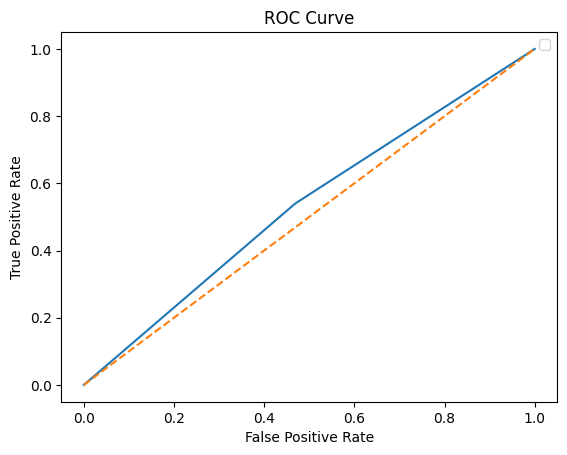

In [194]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [195]:
btc_hourly_test = btc_hourly[btc_hourly.index.isin(list(test_idx))]

In [196]:
btc_hourly_test

,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4,close_log_return_lag_5,close_log_return_direction
timestamp,,,,,,,,,,,,
2021-01-28 06:00:00,31729.16,31876.63,31521.37,31564.58,3487.710790,-0.005201,0.013595,-0.003302,0.013546,0.003226,0.006826,0
2021-01-28 07:00:00,31564.75,31597.76,31080.00,31170.53,2809.483770,-0.012563,-0.005201,0.013595,-0.003302,0.013546,0.003226,0
2021-01-28 08:00:00,31170.20,31303.15,31001.55,31070.47,2699.222378,-0.003215,-0.012563,-0.005201,0.013595,-0.003302,0.013546,0
2021-01-28 09:00:00,31070.47,31483.44,30812.26,31466.91,3531.477648,0.012679,-0.003215,-0.012563,-0.005201,0.013595,-0.003302,1
2021-01-28 10:00:00,31473.33,31585.39,31030.00,31490.29,3025.903137,0.000743,0.012679,-0.003215,-0.012563,-0.005201,0.013595,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-29 15:00:00,87014.40,87039.51,84366.56,84934.02,8241.956400,-0.024199,-0.011864,-0.000776,0.003122,-0.001137,0.000619,0
2026-01-29 16:00:00,84934.02,85392.20,84268.17,85270.00,4076.758790,0.003948,-0.024199,-0.011864,-0.000776,0.003122,-0.001137,1
2026-01-29 17:00:00,85270.01,85638.30,84012.78,84261.66,2652.679470,-0.011896,0.003948,-0.024199,-0.011864,-0.000776,0.003122,0


In [197]:
# Evaluate Models Profitability (Out-of-sample)
btc_hourly_test['y_pred_binary'] = y_pred
btc_hourly_test['y_pred_proba'] = y_prob

C:\Users\asus\AppData\Local\Temp\ipykernel_24068\2221460965.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['y_pred_binary'] = y_pred
C:\Users\asus\AppData\Local\Temp\ipykernel_24068\2221460965.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['y_pred_proba'] = y_prob


In [198]:
btc_hourly_test[['close_log_return','y_pred_binary', 'y_pred_proba']]

,close_log_return,y_pred_binary,y_pred_proba
timestamp,,,
2021-01-28 06:00:00,-0.005201,0.0,0.489774
2021-01-28 07:00:00,-0.012563,1.0,0.553261
2021-01-28 08:00:00,-0.003215,1.0,0.565693
2021-01-28 09:00:00,0.012679,1.0,0.546291
2021-01-28 10:00:00,0.000743,0.0,0.444464
...,...,...,...
2026-01-29 15:00:00,-0.024199,0.0,0.493041
2026-01-29 16:00:00,0.003948,1.0,0.606463
2026-01-29 17:00:00,-0.011896,1.0,0.778548


In [199]:
btc_hourly_test['direction_signal'] = np.where(btc_hourly_test['y_pred_binary'] == 1, 1, -1)


C:\Users\asus\AppData\Local\Temp\ipykernel_24068\1512324759.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['direction_signal'] = np.where(btc_hourly_test['y_pred_binary'] == 1, 1, -1)


In [200]:
btc_hourly_test[['close_log_return','direction_signal','y_pred_binary']]


,close_log_return,direction_signal,y_pred_binary
timestamp,,,
2021-01-28 06:00:00,-0.005201,-1,0.0
2021-01-28 07:00:00,-0.012563,1,1.0
2021-01-28 08:00:00,-0.003215,1,1.0
2021-01-28 09:00:00,0.012679,1,1.0
2021-01-28 10:00:00,0.000743,-1,0.0
...,...,...,...
2026-01-29 15:00:00,-0.024199,-1,0.0
2026-01-29 16:00:00,0.003948,1,1.0
2026-01-29 17:00:00,-0.011896,1,1.0


In [201]:
btc_hourly_test['direction_signal'].value_counts()


direction_signal
 1    6021
-1    5907
Name: count, dtype: int64

In [202]:
# Evaluate Model Profitability
btc_hourly_test['trade_log_return'] = btc_hourly_test['direction_signal'] * btc_hourly_test['close_log_return']


C:\Users\asus\AppData\Local\Temp\ipykernel_24068\1657808731.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['trade_log_return'] = btc_hourly_test['direction_signal'] * btc_hourly_test['close_log_return']


<Axes: xlabel='timestamp'>

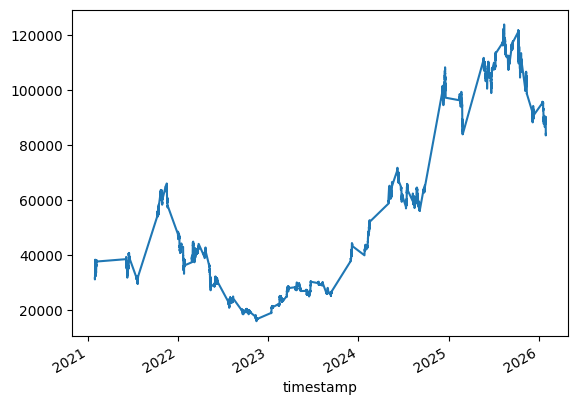

In [203]:
btc_hourly[[ind in btc_hourly_test.index for ind in btc_hourly.index]]['close'].plot()

<Axes: xlabel='timestamp'>

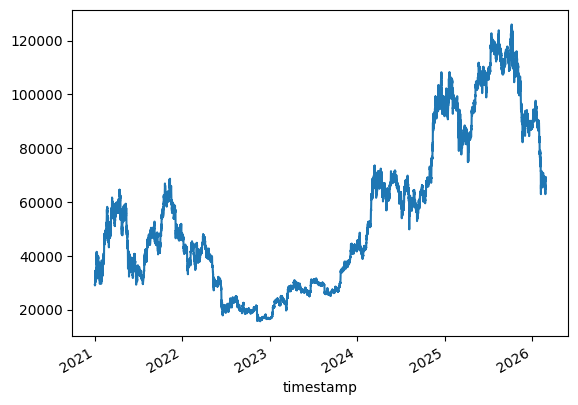

In [204]:
btc_hourly[start:]['close'].plot()

<Axes: xlabel='timestamp'>

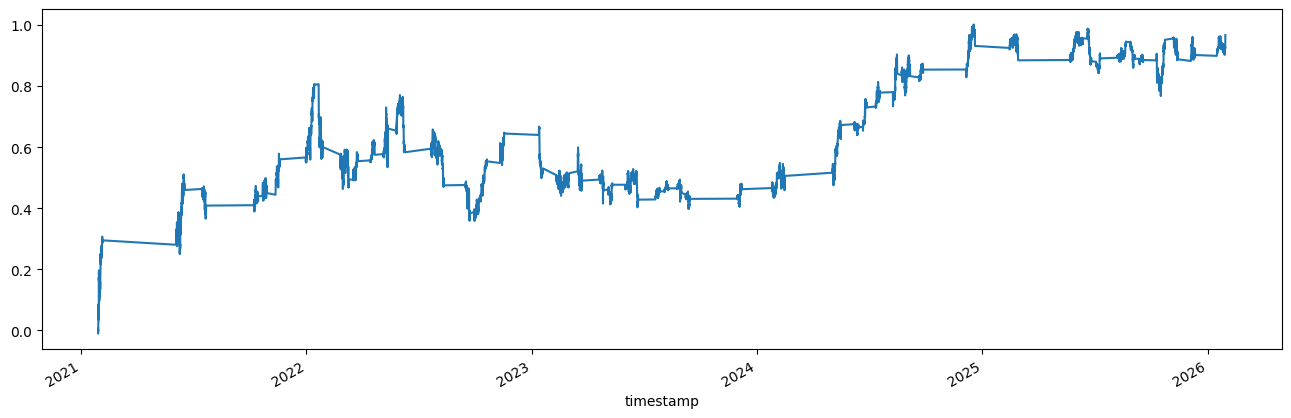

In [205]:
# Sum up Compound Growth Returns

#btc_hourly_test[(btc_hourly_test['y_pred_proba']<0.45)|(btc_hourly_test['y_pred_proba']>0.55)]['trade_log_return'].cumsum().plot(figsize=(16,5))
btc_hourly_test['trade_log_return'].cumsum().plot(figsize=(16,5))


In [206]:
# Equity Curve
trade_size = 50.0
btc_hourly_test['pre_trade_value'] = trade_size
btc_hourly_test['post_trade_value'] = np.exp(btc_hourly_test['trade_log_return']) * trade_size
btc_hourly_test[['pre_trade_value','post_trade_value','trade_log_return']]

C:\Users\asus\AppData\Local\Temp\ipykernel_24068\2652511958.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['pre_trade_value'] = trade_size
C:\Users\asus\AppData\Local\Temp\ipykernel_24068\2652511958.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['post_trade_value'] = np.exp(btc_hourly_test['trade_log_return']) * trade_size


,pre_trade_value,post_trade_value,trade_log_return
timestamp,,,
2021-01-28 06:00:00,50.0,50.260704,0.005201
2021-01-28 07:00:00,50.0,49.375804,-0.012563
2021-01-28 08:00:00,50.0,49.839496,-0.003215
2021-01-28 09:00:00,50.0,50.637969,0.012679
2021-01-28 10:00:00,50.0,49.962877,-0.000743
...,...,...,...
2026-01-29 15:00:00,50.0,51.224704,0.024199
2026-01-29 16:00:00,50.0,50.197789,0.003948
2026-01-29 17:00:00,50.0,49.408737,-0.011896


In [207]:
btc_hourly_test['trade_gross_pnl'] = btc_hourly_test['post_trade_value'] - btc_hourly_test['pre_trade_value']
btc_hourly_test[['pre_trade_value','post_trade_value','trade_log_return','trade_gross_pnl']]

C:\Users\asus\AppData\Local\Temp\ipykernel_24068\1018174758.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['trade_gross_pnl'] = btc_hourly_test['post_trade_value'] - btc_hourly_test['pre_trade_value']


,pre_trade_value,post_trade_value,trade_log_return,trade_gross_pnl
timestamp,,,,
2021-01-28 06:00:00,50.0,50.260704,0.005201,0.260704
2021-01-28 07:00:00,50.0,49.375804,-0.012563,-0.624196
2021-01-28 08:00:00,50.0,49.839496,-0.003215,-0.160504
2021-01-28 09:00:00,50.0,50.637969,0.012679,0.637969
2021-01-28 10:00:00,50.0,49.962877,-0.000743,-0.037123
...,...,...,...,...
2026-01-29 15:00:00,50.0,51.224704,0.024199,1.224704
2026-01-29 16:00:00,50.0,50.197789,0.003948,0.197789
2026-01-29 17:00:00,50.0,49.408737,-0.011896,-0.591263


C:\Users\asus\AppData\Local\Temp\ipykernel_24068\3910178235.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['equity_curve_gross'] = trade_size + btc_hourly_test['trade_gross_pnl'].cumsum()


<Axes: xlabel='timestamp'>

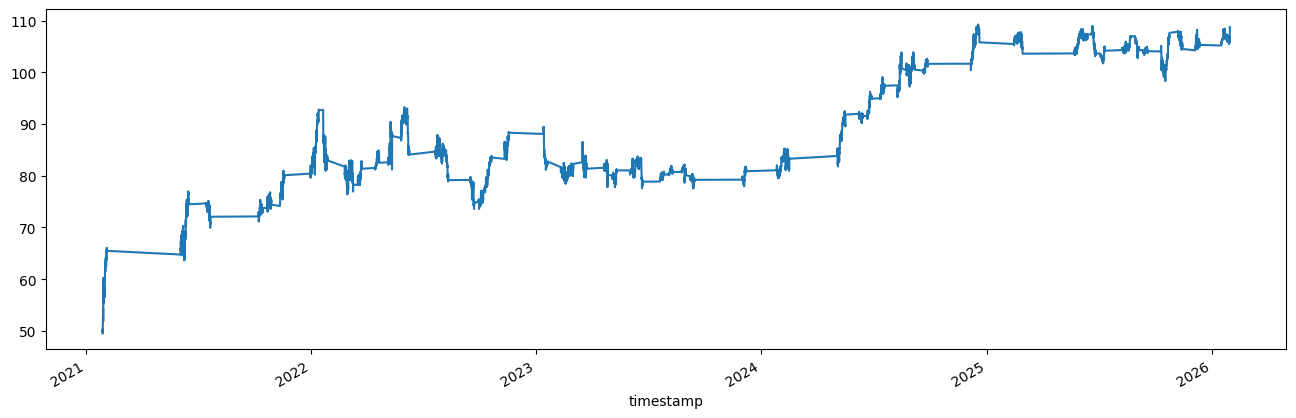

In [208]:
btc_hourly_test['equity_curve_gross'] = trade_size + btc_hourly_test['trade_gross_pnl'].cumsum()
btc_hourly_test['equity_curve_gross'].plot(figsize=(16,5))

In [209]:
btc_hourly_test['trade_gross_pnl'].mean()


np.float64(0.004924372697291016)

In [210]:
trade_size + btc_hourly_test['trade_gross_pnl'].sum()


np.float64(108.73791753328724)

In [211]:
(trade_size + btc_hourly_test['trade_gross_pnl'].sum()) / trade_size


np.float64(2.174758350665745)

In [212]:
btc_hourly_test[['pre_trade_value','post_trade_value','trade_log_return','trade_gross_pnl']]


,pre_trade_value,post_trade_value,trade_log_return,trade_gross_pnl
timestamp,,,,
2021-01-28 06:00:00,50.0,50.260704,0.005201,0.260704
2021-01-28 07:00:00,50.0,49.375804,-0.012563,-0.624196
2021-01-28 08:00:00,50.0,49.839496,-0.003215,-0.160504
2021-01-28 09:00:00,50.0,50.637969,0.012679,0.637969
2021-01-28 10:00:00,50.0,49.962877,-0.000743,-0.037123
...,...,...,...,...
2026-01-29 15:00:00,50.0,51.224704,0.024199,1.224704
2026-01-29 16:00:00,50.0,50.197789,0.003948,0.197789
2026-01-29 17:00:00,50.0,49.408737,-0.011896,-0.591263


In [213]:
btc_hourly_test['cum_trade_log_return'] = btc_hourly_test['trade_log_return'].cumsum()
btc_hourly_test['post_trade_value'] = np.exp(btc_hourly_test['cum_trade_log_return']) * trade_size
btc_hourly_test['pre_trade_value'] = btc_hourly_test['post_trade_value'].shift()


C:\Users\asus\AppData\Local\Temp\ipykernel_24068\1149602882.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['cum_trade_log_return'] = btc_hourly_test['trade_log_return'].cumsum()
C:\Users\asus\AppData\Local\Temp\ipykernel_24068\1149602882.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['post_trade_value'] = np.exp(btc_hourly_test['cum_trade_log_return']) * trade_size
C:\Users\asus\AppData\Local\Temp\ipykernel_24068\1149602882.py:3: SettingWithCopyWarning: 
A value is 

In [214]:
btc_hourly_test[['trade_log_return','cum_trade_log_return','pre_trade_value','post_trade_value']]


,trade_log_return,cum_trade_log_return,pre_trade_value,post_trade_value
timestamp,,,,
2021-01-28 06:00:00,0.005201,0.005201,NaN,50.260704
2021-01-28 07:00:00,-0.012563,-0.007362,50.260704,49.633253
2021-01-28 08:00:00,-0.003215,-0.010577,49.633253,49.473926
2021-01-28 09:00:00,0.012679,0.002101,49.473926,50.105182
2021-01-28 10:00:00,-0.000743,0.001359,50.105182,50.067982
...,...,...,...,...
2026-01-29 15:00:00,0.024199,0.959344,127.379147,130.499181
2026-01-29 16:00:00,0.003948,0.963292,130.499181,131.015406
2026-01-29 17:00:00,-0.011896,0.951396,131.015406,129.466115


In [215]:
btc_hourly_test['pre_trade_value'].fillna(trade_size, inplace=True)


C:\Users\asus\AppData\Local\Temp\ipykernel_24068\3933173128.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  btc_hourly_test['pre_trade_value'].fillna(trade_size, inplace=True)
C:\Users\asus\AppData\Local\Temp\ipykernel_24068\3933173128.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['pre_trade_value'].fillna(trade_size,

In [216]:
btc_hourly_test[['trade_log_return','cum_trade_log_return','pre_trade_value','post_trade_value']]


,trade_log_return,cum_trade_log_return,pre_trade_value,post_trade_value
timestamp,,,,
2021-01-28 06:00:00,0.005201,0.005201,50.000000,50.260704
2021-01-28 07:00:00,-0.012563,-0.007362,50.260704,49.633253
2021-01-28 08:00:00,-0.003215,-0.010577,49.633253,49.473926
2021-01-28 09:00:00,0.012679,0.002101,49.473926,50.105182
2021-01-28 10:00:00,-0.000743,0.001359,50.105182,50.067982
...,...,...,...,...
2026-01-29 15:00:00,0.024199,0.959344,127.379147,130.499181
2026-01-29 16:00:00,0.003948,0.963292,130.499181,131.015406
2026-01-29 17:00:00,-0.011896,0.951396,131.015406,129.466115


In [217]:
btc_hourly_test['trade_gross_pnl'] = btc_hourly_test['post_trade_value'] - btc_hourly_test['pre_trade_value']


C:\Users\asus\AppData\Local\Temp\ipykernel_24068\2975625528.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['trade_gross_pnl'] = btc_hourly_test['post_trade_value'] - btc_hourly_test['pre_trade_value']


In [218]:
btc_hourly_test['trade_gross_pnl'].mean()

np.float64(0.006834398884508634)

In [219]:
np.exp(btc_hourly_test['trade_log_return'].sum())


np.float64(2.630414197888382)

In [220]:
np.exp(btc_hourly_test['trade_log_return'].sum()) * trade_size


np.float64(131.5207098944191)

<Axes: xlabel='timestamp'>

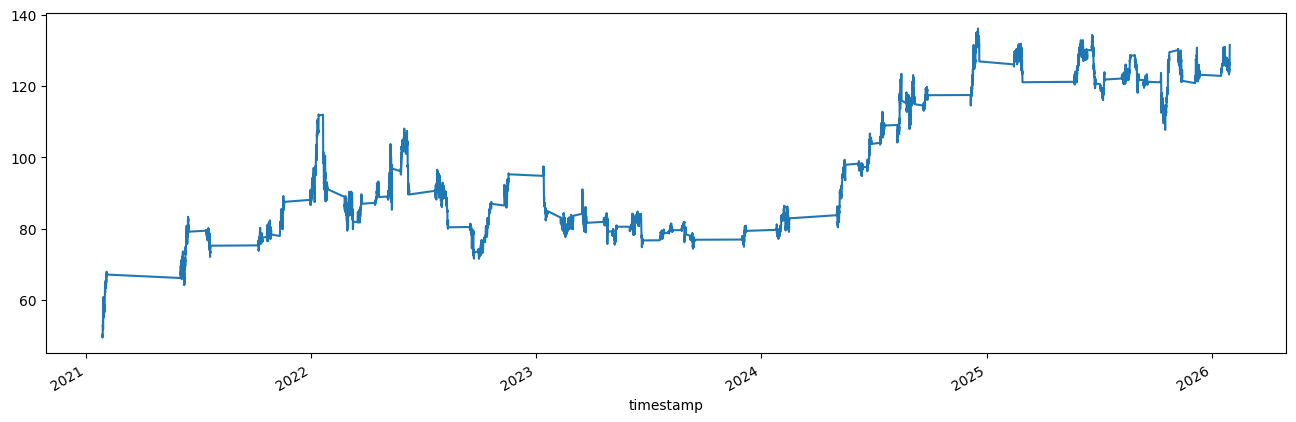

In [221]:
(np.exp(btc_hourly_test['trade_log_return'].cumsum()) * trade_size).plot(figsize=(16,5))


In [228]:
days_in_year = 365
hours_in_day = 24
t = days_in_year * hours_in_day

btc_hourly_test['trade_log_return'].mean() / btc_hourly_test['trade_log_return'].std() * np.sqrt(t)

np.float64(1.2862815598326336)

In [229]:
# Equity and Leverage
equity = 50.0
leverage = 2.0

In [230]:
btc_hourly_test['post_trade_value'] = np.exp(btc_hourly_test['cum_trade_log_return']) * trade_size * leverage
btc_hourly_test['pre_trade_value'] = btc_hourly_test['post_trade_value'].shift().fillna(trade_size * leverage)
btc_hourly_test['trade_gross_pnl'] = btc_hourly_test['post_trade_value'] - btc_hourly_test['pre_trade_value']
btc_hourly_test[['pre_trade_value','post_trade_value','trade_gross_pnl']]


C:\Users\asus\AppData\Local\Temp\ipykernel_24068\952654768.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['post_trade_value'] = np.exp(btc_hourly_test['cum_trade_log_return']) * trade_size * leverage
C:\Users\asus\AppData\Local\Temp\ipykernel_24068\952654768.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_hourly_test['pre_trade_value'] = btc_hourly_test['post_trade_value'].shift().fillna(trade_size * leverage)
C:\Users\asus\AppData\Local\Temp\ipykernel_24068\952654768.py:3: Sett

,pre_trade_value,post_trade_value,trade_gross_pnl
timestamp,,,
2021-01-28 06:00:00,100.000000,100.521407,0.521407
2021-01-28 07:00:00,100.521407,99.266505,-1.254902
2021-01-28 08:00:00,99.266505,98.947851,-0.318654
2021-01-28 09:00:00,98.947851,100.210365,1.262513
2021-01-28 10:00:00,100.210365,100.135963,-0.074401
...,...,...,...
2026-01-29 15:00:00,254.758293,260.998361,6.240068
2026-01-29 16:00:00,260.998361,262.030812,1.032451
2026-01-29 17:00:00,262.030812,258.932230,-3.098583


3 important achievements:
1. executed the entry/exit signal computation
2. performed the trade sizing
3. tested the leveraged potential trade

In [231]:
total_compound_return = np.exp(btc_hourly_test['trade_log_return'].sum())
total_compound_return

np.float64(2.630414197888382)